In [41]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelBinarizer

import tensorflow as tf
from tensorflow import keras
from keras.layers import Dense, Dropout, Input, Conv2D  ,BatchNormalization, MaxPool2D, Activation
from keras.losses import MeanAbsolutePercentageError
from keras.optimizers import AdamW
from keras.models import Model, Sequential



In [20]:
culomns_name = ["bedrooms", "bathrooms", "area", "zipcode", "price"]
df = pd.read_csv("/mnt/e/Deep Learning/data/Houses Dataset/HousesInfo.txt", sep=" ", header=None, names=culomns_name)
df.head(10)

,bedrooms,bathrooms,area,zipcode,price
0,4,4.0,4053,85255,869500
1,4,3.0,3343,36372,865200
2,3,4.0,3923,85266,889000
3,5,5.0,4022,85262,910000
4,3,4.0,4116,85266,971226
5,4,5.0,4581,85266,1249000
6,3,4.0,2544,85262,799000
7,4,5.0,5524,85266,1698000
8,3,4.0,4229,85255,1749000
9,4,5.0,3550,85262,1500000


In [21]:
counts = df["zipcode"].value_counts()
type(counts)
unique_zipcodes = counts.index.to_numpy()
counts_zipcodes = counts.values

print(counts_zipcodes.shape)

(49,)


In [22]:
for zipcode, count in zip(unique_zipcodes, counts_zipcodes):
    if count >= 10:
        print(f"{zipcode} --> {count}")

92276 --> 100
93510 --> 60
93446 --> 54
92880 --> 49
94501 --> 41
91901 --> 32
92677 --> 26
94531 --> 22
85255 --> 12
96019 --> 12
85266 --> 11
81524 --> 11
92021 --> 11
93111 --> 11
95220 --> 10


In [23]:
list_least_zipcode = counts[counts.values < 25].index.to_list()

for zipcode in list_least_zipcode:
    idxs = df[df['zipcode'] == zipcode].index
    df.drop(idxs, inplace=True)
    

In [24]:
df

,bedrooms,bathrooms,area,zipcode,price
30,5,3.0,2520,93446,789000
32,3,2.0,1802,93446,365000
39,3,3.0,2146,93446,455000
80,4,2.5,2464,91901,599000
81,2,2.0,1845,91901,529800
...,...,...,...,...,...
499,4,4.0,3000,93446,1495000
500,3,2.0,2330,93446,599900
501,3,2.5,1339,93446,344900
502,3,2.0,1472,93446,309995


In [25]:
df["zipcode"].value_counts()

zipcode
92276    100
93510     60
93446     54
92880     49
94501     41
91901     32
92677     26
Name: count, dtype: int64

In [26]:
image_name_list = os.listdir("/mnt/e/Deep Learning/data/Houses Dataset/concats")
key_sort = sorted([int(name.split("_")[0]) for name in image_name_list])

def extract_first_number(path):
    return int(path.split("_")[0].split("/")[-1])

image_path_list = sorted([os.path.join("/mnt/e/Deep Learning/data/Houses Dataset/concats", image_name) for image_name in image_name_list], key=extract_first_number)

In [27]:
images = np.array([cv2.imread(path) for path in image_path_list])
print(images.shape)

(362, 64, 64, 3)


In [28]:
train_df, val_df, train_images, val_images = train_test_split(df, images, test_size=0.2, random_state=42)

print(f"Shape of train dataframe: {train_df.shape}")
print(f"Shape of train images: {train_images.shape}")

print(f"Shape of val dataframe: {val_df.shape}")
print(f"Shape of val images: {val_images.shape}")

Shape of train dataframe: (289, 5)
Shape of train images: (289, 64, 64, 3)
Shape of val dataframe: (73, 5)
Shape of val images: (73, 64, 64, 3)


In [29]:
y_train = train_df['price']
y_val = val_df['price']

train_df = train_df[["bedrooms", "bathrooms", "area", "zipcode"]]
val_df = val_df[["bedrooms", "bathrooms", "area", "zipcode"]]

In [30]:
MaxTrain = y_train.max()

y_train /= MaxTrain
y_val /= MaxTrain

In [34]:
bn = LabelBinarizer().fit(train_df["zipcode"])

train_data_categorical = bn.transform(train_df['zipcode'])
val_data_categorical = bn.transform(val_df['zipcode'])

train_data_categorical.shape

(289, 7)

In [35]:
mn = MinMaxScaler()

train_df_norm = mn.fit_transform(train_df[['bedrooms', 'bathrooms', 'area']])
val_df_norm = mn.transform(val_df[['bedrooms', 'bathrooms', 'area']])

In [39]:
train_data = np.hstack((train_df_norm, train_data_categorical))
val_data = np.hstack((val_df_norm, val_data_categorical))

print(f"Number of features in train data is: {train_data.shape[1]}")
print(f"Number of features in val data is: {val_data.shape[1]}")

Number of features in train data is: 10
Number of features in val data is: 10


In [43]:
height, width, num_channels = (64, 64, 3)

input1 = Input(shape=(train_data.shape[-1], ))
x1 = Dense(8, activation='relu')(input1)
out1 = Dense(4, activation='relu')(x1)


input2 = keras.layers.Input(shape=(height, width, num_channels))

x = Conv2D(16, (3, 3), padding='same')(input2)
x = Activation('relu')(x)
x = BatchNormalization()(x)
x = MaxPool2D((2, 2))(x)

x = Conv2D(32, (3, 3), padding='same')(x)
x = Activation('relu')(x)
x = BatchNormalization()(x)
x = MaxPool2D((2, 2))(x)

x = Conv2D(64, (3, 3), padding='same')(x)
x = Activation('relu')(x)
x = BatchNormalization()(x)
x = MaxPool2D((2, 2))(x)

x = keras.layers.Flatten()(x)

x = keras.layers.Dense(16)(x)
x = keras.layers.Activation('relu')(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Dropout(0.2)(x)

x = keras.layers.Dense(4)(x)
x = keras.layers.Activation('relu')(x)
x = keras.layers.BatchNormalization()(x)
out2 = keras.layers.Dropout(0.2)(x)

concated = keras.layers.concatenate([out1, out2])

x = Dense(4, activation='relu')(concated)
x = Dropout(0.5)(x)

output = Dense(1, activation='linear')(x)

model = Model([input1, input2], output)

W0000 00:00:1778200329.563057   10213 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [44]:
model.compile(optimizer=AdamW(learning_rate=0.001),
              loss=MeanAbsolutePercentageError)

In [48]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 64, 64,    │        448 │ input_layer_1[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 64, 64,    │          0 │ conv2d[0][0]      │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64, 64,    │         64 │ activation[0][0]  │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 32, 32,    │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 32, 32,    │          0 │ conv2d_1[0][0]    │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ activation_1[0][… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 16, 16,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 16, 16,    │          0 │ conv2d_2[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        256 │ activation_2[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 8, 8, 64)  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 4096)      │          0 │ max_pooling2d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 16)        │     65,552 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 16)        │          0 │ dense_2[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16)        │         64 │ activation_3[0][… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 89,897 (351.16 KB)

 Trainable params: 89,633 (350.13 KB)

 Non-trainable params: 264 (1.03 KB)

In [49]:
history = model.fit([train_data, train_images], y_train, validation_data=([val_data, val_images], y_val), batch_size=8, epochs=100)

Epoch 1/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - loss: 1070.0248 - val_loss: 195.6997
Epoch 2/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 836.8155 - val_loss: 182.6943
Epoch 3/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 717.3122 - val_loss: 138.1983
Epoch 4/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 549.9398 - val_loss: 126.6187
Epoch 5/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 445.9976 - val_loss: 212.2732
Epoch 6/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 456.8761 - val_loss: 290.6022
Epoch 7/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 371.4104 - val_loss: 212.2231
Epoch 8/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 285.0805 - val_loss: 1075.6116
Epoch 9/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 257.5529 - val_loss: 396.0292
Epoch 10/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 214.7164 - val_loss: 192.1456
Epoch 11/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 183.2047 - val_loss: 122.0082
Epoch 

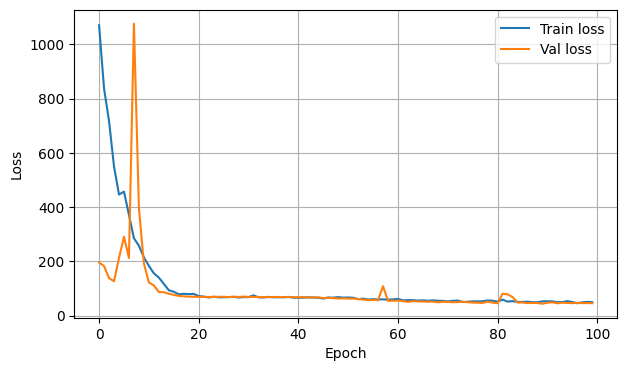

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()
